<center>
<p style="text-align: center;">&nbsp;</p>
<table class="center" bgcolor="white">
    <tr>
    <td rowspan="4"><img src="https://i.ibb.co/PYS9G0H/trust-logo.png" alt="CKPCET" width="90" height="90" /></td>
    <td><h4 style="text-align: center;"><span style="font-family: Cambria, Georgia, Times, 'Times New Roman', serif;">C.K.Pithawala College of Engineering and Technology, Surat</br></br>Subject: Python for Data Science(3150713)<br /></br>Computer Engineering Department</br><br />Submitted To: Prof. Mithila D. Parekh</td>
    <td rowspan="4"><img src="https://i.ibb.co/2dhpLnb/institute-logo.png" alt="CKPCET" width="90" height="90"/></td>
  </tr>
  
</table>
</center>

## Team Member:

1.   230090107112 : Parekh Khant
2.   230090107002 : Afinwala Hitesh

# Dataset

## About DataSet
- Link : https://www.kaggle.com/datasets/nikolaireeds/dmart-grocery-sales
- Description : This data set about the sales of Dmart stores which is located tamil nadu. This data set give the information of the customer, their order, city, regions and sales and profit of products.

## Goal of analysis
- The main objective of this analysis is to get idea of which category and sub category are most purchased based on city and region. By this analysis we can get idea of of which category and subcategory provides the most profit.
- After analysis we will predict which category and subcategory have to be increase in the next year to achieve targeted profit.

In [78]:
# loading the dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("DMart_Grocery_Sales_-_Retail_Analytics_Dataset.csv")
df

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu
...,...,...,...,...,...,...,...,...,...,...,...
9989,OD9990,Sudeep,"Eggs, Meat & Fish",Eggs,Madurai,12/24/2015,West,945,0.16,359.10,Tamil Nadu
9990,OD9991,Alan,Bakery,Biscuits,Kanyakumari,07-12-2015,West,1195,0.26,71.70,Tamil Nadu
9991,OD9992,Ravi,Food Grains,Rice,Bodi,06-06-2017,West,1567,0.16,501.44,Tamil Nadu
9992,OD9993,Peer,Oil & Masala,Spices,Pudukottai,10/16/2018,West,1659,0.15,597.24,Tamil Nadu


## Overview of data set

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Category       9994 non-null   object 
 3   Sub Category   9994 non-null   object 
 4   City           9994 non-null   object 
 5   Order Date     9994 non-null   object 
 6   Region         9994 non-null   object 
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.0+ KB


In [80]:
print("Shape of Dataset:",df.shape, end="\n\n")
print("Columns in data set:\n",df.columns)
print(f"\nData Types: \n{df.dtypes}\n")
print(f"Missing values in each Column: \n{df.isnull().sum()}\n")
print(f"Total Missing Value: {df.isnull().sum().sum()}")

Shape of Dataset: (9994, 11)

Columns in data set:
 Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State'],
      dtype='object')

Data Types: 
Order ID          object
Customer Name     object
Category          object
Sub Category      object
City              object
Order Date        object
Region            object
Sales              int64
Discount         float64
Profit           float64
State             object
dtype: object

Missing values in each Column: 
Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

Total Missing Value: 0


In [81]:
data_map = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Missing Values": df.isnull().sum()
})
data_map

,Column,Data Type,Unique Values,Missing Values
Order ID,Order ID,object,9994,0
Customer Name,Customer Name,object,50,0
Category,Category,object,7,0
Sub Category,Sub Category,object,23,0
City,City,object,24,0
Order Date,Order Date,object,1236,0
Region,Region,object,5,0
Sales,Sales,int64,1989,0
Discount,Discount,float64,26,0
Profit,Profit,float64,8380,0


## Categorial data and Formating Date

In [83]:
#Categoty, subcategory, region column can be set as categoricalcate_col = ["Category", "Sub Category", "Region"]
cate_col = ["Category", "Sub Category", "Region"]
for col in cate_col:
    df[col] = df[col].astype('category')

#renaming level
df["Region"] = df["Region"].replace({
    "South" : "S",
    "North" : "N",
    "East" : "E",
    "West" : "W"
})

#Formating date
df["Order Date"] = pd.to_datetime(df["Order Date"], format='mixed')

#extracting month and year
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df.head(3)

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State,Month,Year
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-11-08,N,1254,0.12,401.28,Tamil Nadu,11,2017
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-11-08,S,749,0.18,149.80,Tamil Nadu,11,2017
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-06-12,W,2360,0.21,165.20,Tamil Nadu,6,2017


## EDA

Total Sales: 14956982
Total profit: 3747121.1999999997


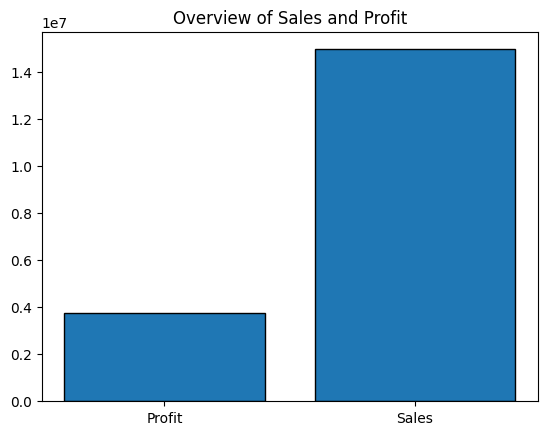

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. total sales and profit
total_p = df['Profit'].sum()
total_s = df['Sales'].sum()
print(f"Total Sales: {total_s}")
print(f"Total profit: {total_p}")

plt.bar(['Profit','Sales'], [total_p, total_s], edgecolor='black')
plt.title("Overview of Sales and Profit")
plt.show()

Category
Eggs, Meat & Fish    2267401
Snacks               2237546
Food Grains          2115272
Bakery               2112281
Fruits & Veggies     2100727
Beverages            2085313
Oil & Masala         2038442
Name: Sales, dtype: int64



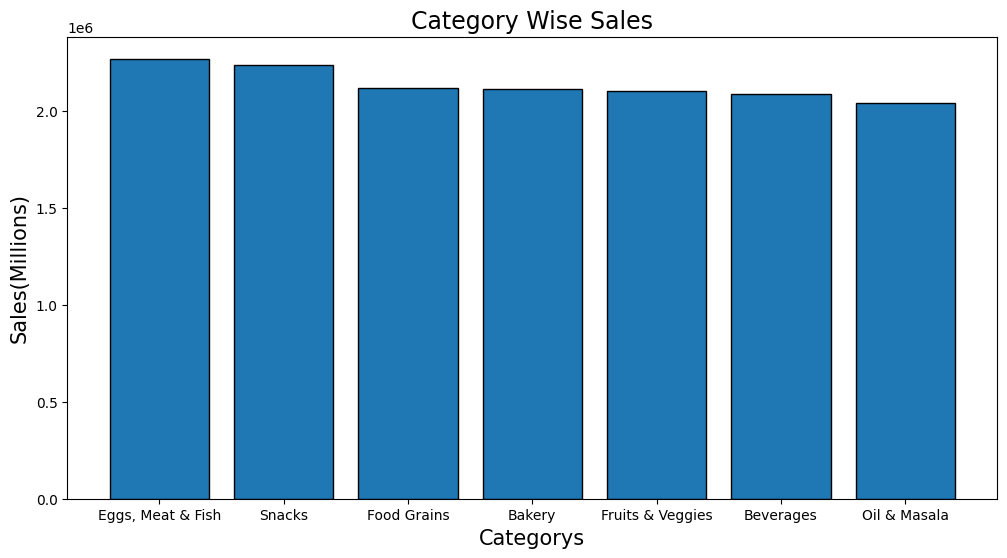

In [85]:
# 2. Sales by category
category_sale = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sale, end='\n\n')

plt.figure(figsize=(12,6))
plt.bar(category_sale.index, category_sale.values, edgecolor='black')
plt.title('Category Wise Sales', fontsize=17)
plt.xlabel('Categorys',fontsize=15)
plt.ylabel('Sales(Millions)',fontsize=15)
plt.show()

Category
Snacks               568178.85
Eggs, Meat & Fish    567357.22
Fruits & Veggies     530400.38
Food Grains          529162.64
Bakery               528521.06
Beverages            525605.76
Oil & Masala         497895.29
Name: Profit, dtype: float64



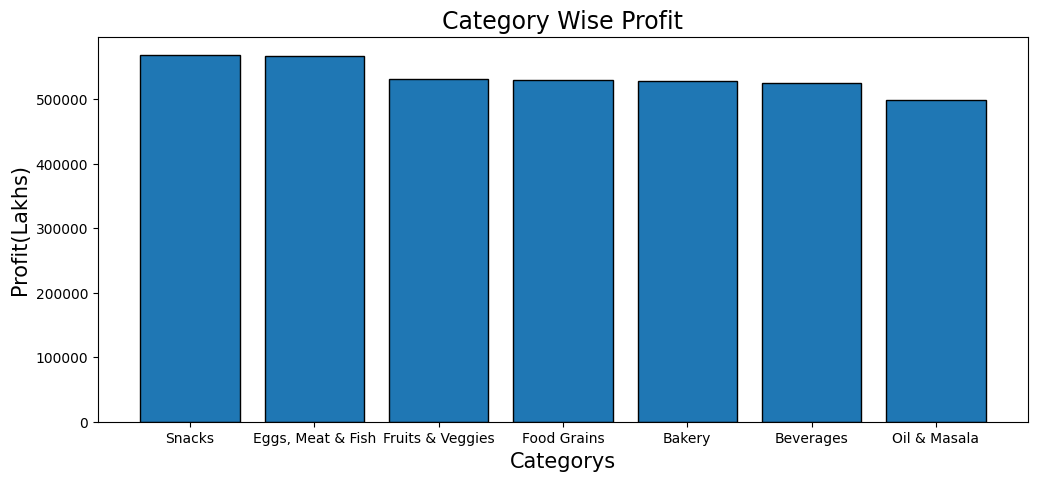

In [86]:
# 3. Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(category_profit, end='\n\n')

plt.figure(figsize=(12,5))
plt.bar(category_profit.index, category_profit.values, edgecolor='black')
plt.title('Category Wise Profit', fontsize=17)
plt.xlabel('Categorys',fontsize=15)
plt.ylabel('Profit(Lakhs)',fontsize=15)
plt.show()

Sub Category
Health Drinks         1051439
Soft Drinks           1033874
Cookies                768213
Breads & Buns          742586
Noodles                735435
Chocolates             733898
Masalas                697480
Cakes                  685612
Biscuits               684083
Spices                 672876
Edible Oil & Ghee      668086
Mutton                 611200
Eggs                   575156
Fish                   560548
Organic Staples        558929
Fresh Fruits           551212
Atta & Flour           534649
Fresh Vegetables       525842
Dals & Pulses          523371
Chicken                520497
Organic Vegetables     520271
Organic Fruits         503402
Rice                   498323
Name: Sales, dtype: int64



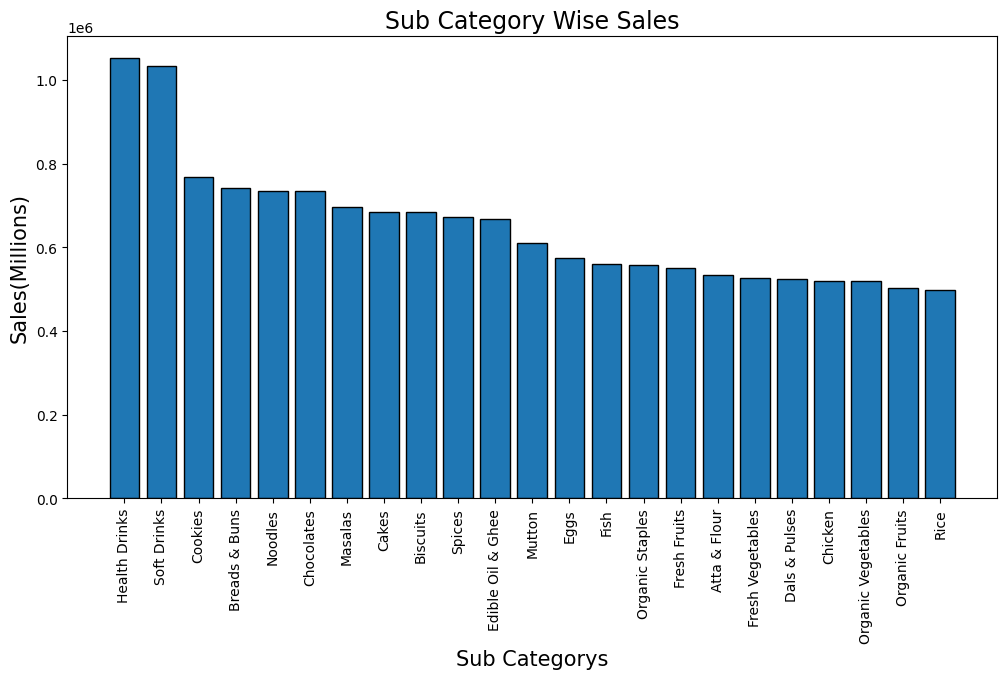

In [87]:
# 4. sub-category by sales
subcategory_sale = df.groupby('Sub Category')['Sales'].sum().sort_values(ascending=False)
print(subcategory_sale, end='\n\n')

plt.figure(figsize=(12,6))
plt.bar(subcategory_sale.index, subcategory_sale.values, edgecolor='black')
plt.title('Sub Category Wise Sales', fontsize=17)
plt.xlabel('Sub Categorys',fontsize=15)
plt.ylabel('Sales(Millions)',fontsize=15)
plt.xticks(rotation=90)
plt.show()

Sub Category
Health Drinks         267469.79
Soft Drinks           258135.97
Noodles               193685.81
Breads & Buns         190764.98
Cookies               190643.70
Chocolates            183849.34
Biscuits              169357.62
Masalas               168999.11
Edible Oil & Ghee     168593.58
Cakes                 168398.46
Spices                160302.60
Mutton                151389.40
Fish                  147248.01
Eggs                  144669.92
Organic Staples       144136.89
Fresh Fruits          134668.35
Organic Vegetables    133596.37
Fresh Vegetables      131273.33
Organic Fruits        130862.33
Dals & Pulses         130232.29
Atta & Flour          127861.10
Rice                  126932.36
Chicken               124049.89
Name: Profit, dtype: float64



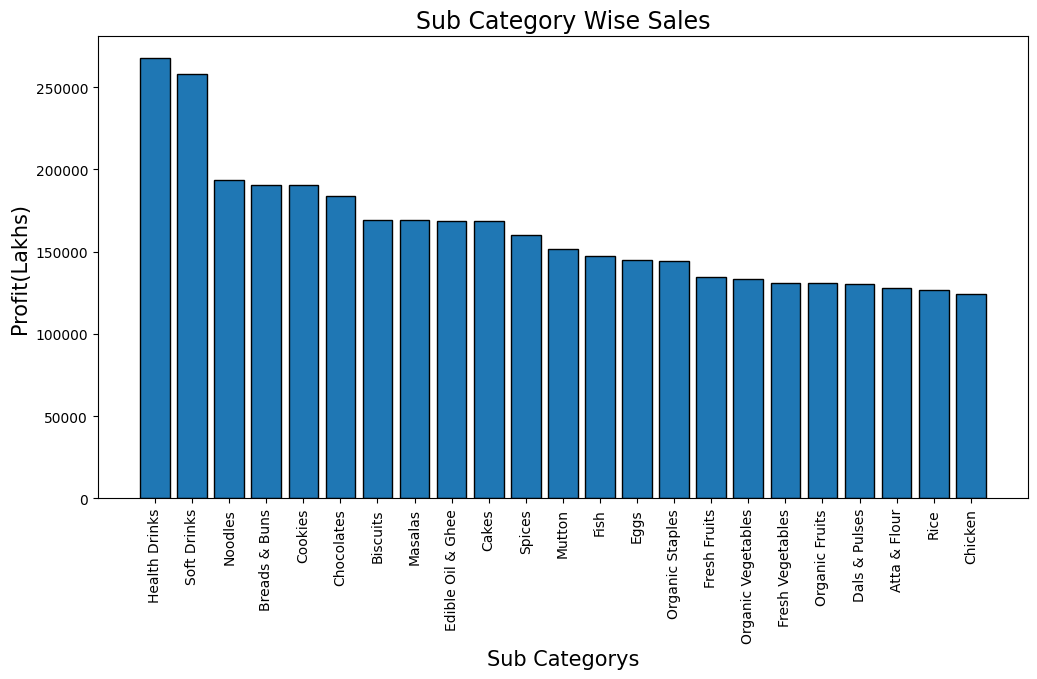

In [88]:
# 5. sub-category by profit
subcategory_sale = df.groupby('Sub Category')['Profit'].sum().sort_values(ascending=False)
print(subcategory_sale, end='\n\n')

plt.figure(figsize=(12,6))
plt.bar(subcategory_sale.index, subcategory_sale.values, edgecolor='black')
plt.title('Sub Category Wise Sales', fontsize=17)
plt.xlabel('Sub Categorys',fontsize=15)
plt.ylabel('Profit(Lakhs)',fontsize=15)
plt.xticks(rotation=90)
plt.show()

City
Kanyakumari       706764
Vellore           676550
Bodi              667177
Tirunelveli       659812
Perambalur        659738
Salem             657093
Pudukottai        653179
Tenkasi           643652
Karur             642273
Krishnagiri       637273
Chennai           634963
Coimbatore        634748
Ramanadhapuram    634386
Cumbum            626047
Madurai           617836
Virudhunagar      606820
Ooty              599292
Namakkal          598530
Viluppuram        581274
Theni             579553
Dindigul          575631
Dharmapuri        571553
Nagercoil         551435
Trichy            541403
Name: Sales, dtype: int64


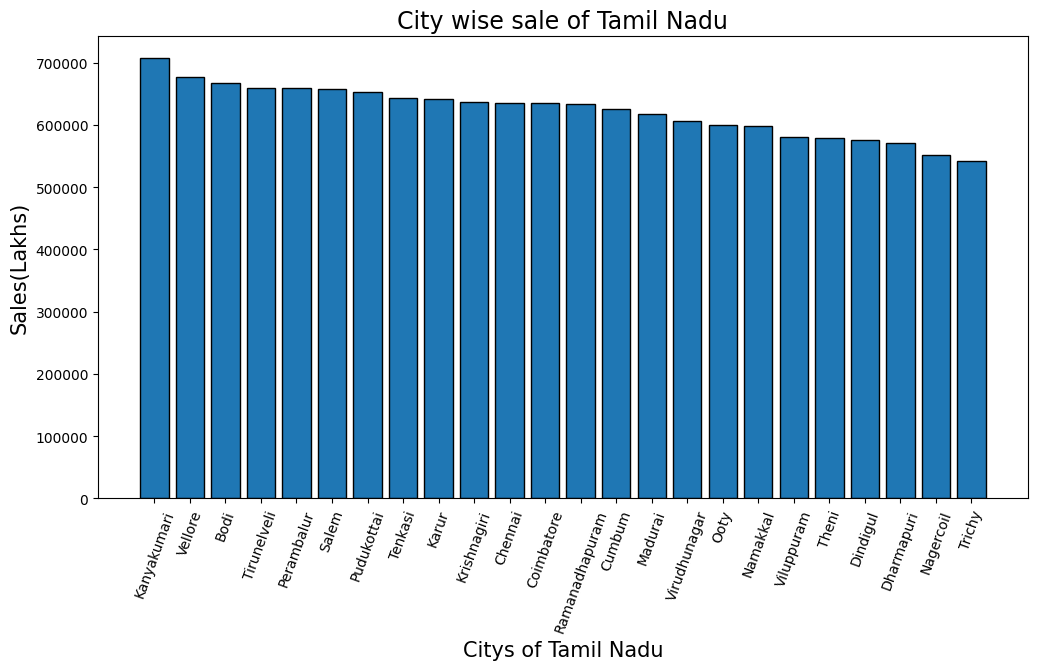

In [89]:
# 6. sales by city
city_sale = df.groupby('City')['Sales'].sum().sort_values(ascending=False)
print(city_sale)

plt.figure(figsize=(12,6))
plt.bar(city_sale.index, city_sale.values, edgecolor='black')
plt.title("City wise sale of Tamil Nadu",fontsize=17)
plt.xlabel('Citys of Tamil Nadu',fontsize=15)
plt.ylabel('Sales(Lakhs)',fontsize=15)
plt.xticks(rotation=70)
plt.show()

Year
2015    2975599
2016    3131959
2017    3871912
2018    4977512
Name: Sales, dtype: int64

Year
2015     752529.11
2016     797192.99
2017     953216.22
2018    1244182.88
Name: Profit, dtype: float64


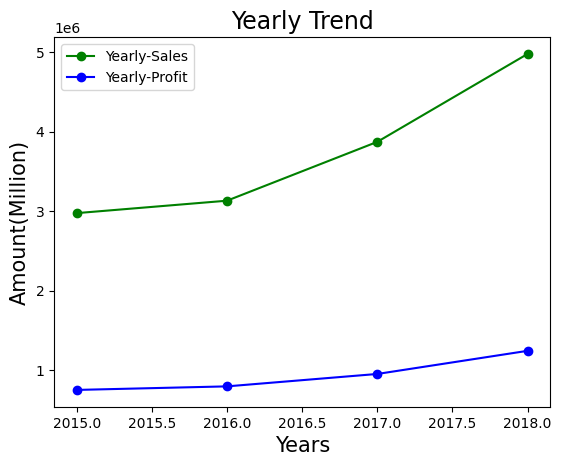

In [90]:
# 7. Yearly sales and profit
yearly_sales = df.groupby('Year')['Sales'].sum()
yearly_profit = df.groupby('Year')['Profit'].sum()
print(yearly_sales, yearly_profit, sep='\n\n')

plt.plot(yearly_sales.index, yearly_sales.values, marker='o',color='green', label='Yearly-Sales')
plt.plot(yearly_profit.index, yearly_profit.values, marker='o',color='blue', label='Yearly-Profit')
plt.title('Yearly Trend',fontsize=17)
plt.ylabel('Amount(Million)',fontsize=15)
plt.xlabel('Years',fontsize=15)
plt.legend()
plt.show()

Region
W          4798743
E          4248368
Central    3468156
S          2440461
N             1254
Name: Sales, dtype: int64

Region
W          1192004.61
E          1074345.58
Central     856806.84
S           623562.89
N              401.28
Name: Profit, dtype: float64



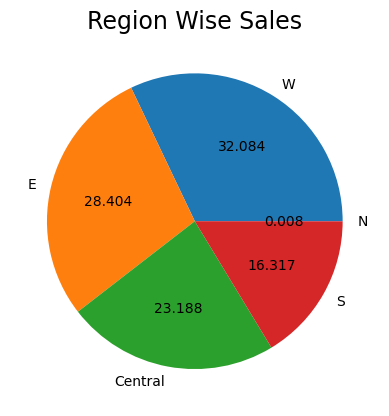

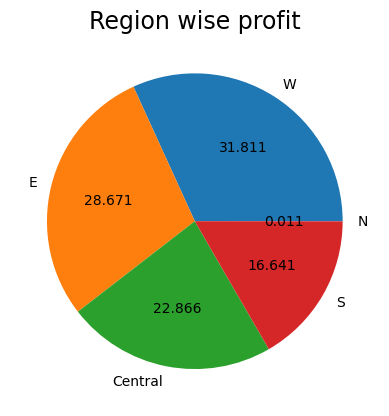

In [91]:
# region wise profit distribution
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
region_sale = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sale, region_profit,sep='\n\n',end='\n\n')

plt.pie(region_sale.values, labels=region_sale.index, autopct='%.3f')
plt.title('Region Wise Sales',fontsize=17)
plt.show()

plt.pie(region_profit.values, labels=region_profit.index, autopct='%.3f')
plt.title('Region wise profit',fontsize=17)
plt.show()

Region   Category         
Central  Snacks               375
         Fruits & Veggies     355
         Beverages            343
         Eggs, Meat & Fish    331
         Food Grains          310
         Bakery               309
         Oil & Masala         300
E        Eggs, Meat & Fish    449
         Snacks               429
         Oil & Masala         416
         Food Grains          393
         Bakery               392
         Beverages            385
         Fruits & Veggies     384
N        Oil & Masala           1
         Bakery                 0
         Beverages              0
         Eggs, Meat & Fish      0
         Food Grains            0
         Fruits & Veggies       0
         Snacks                 0
S        Snacks               251
         Bakery               240
         Fruits & Veggies     234
         Eggs, Meat & Fish    233
         Food Grains          232
         Beverages            227
         Oil & Masala         202
W        Eggs, Meat &

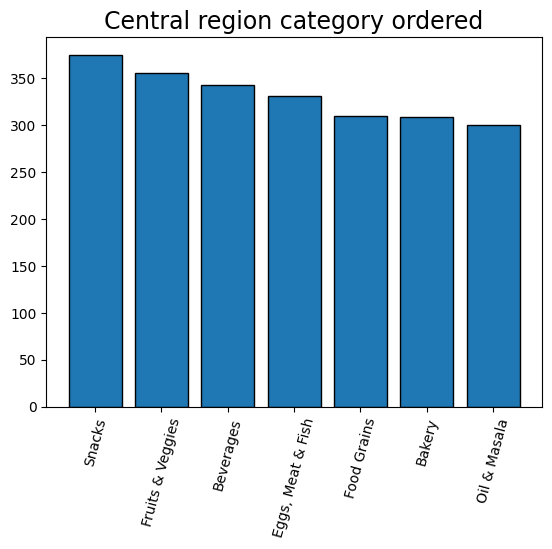

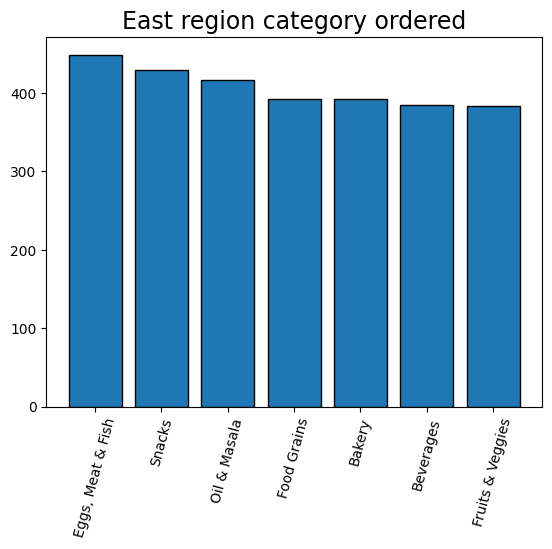

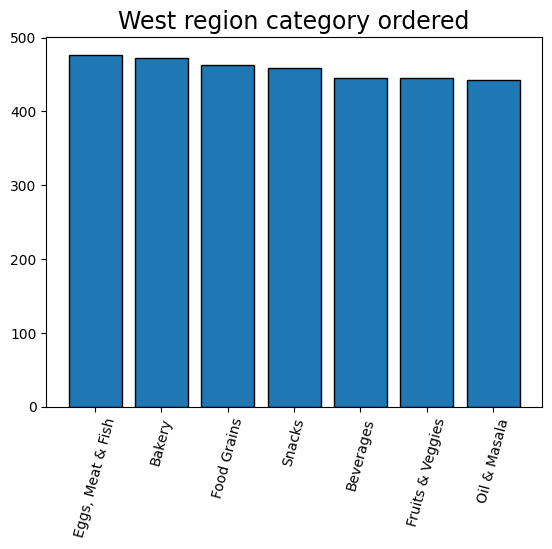

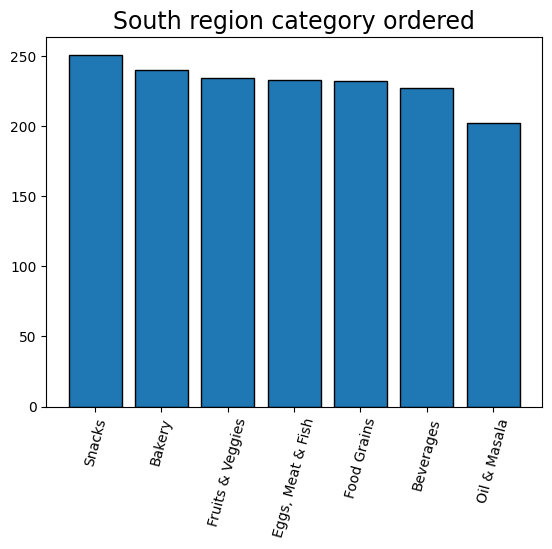

In [92]:
region_cat = df.groupby('Region')['Category'].value_counts()
print(region_cat)

central = region_cat['Central']
east = region_cat['E']
west = region_cat['W']
south = region_cat['S']

plt.title('Central region category ordered',fontsize=17)
plt.bar(central.index,central.values, edgecolor='black')
plt.xticks(rotation=75)
plt.show()

plt.title('East region category ordered',fontsize=17)
plt.bar(east.index,east.values, edgecolor='black')
plt.xticks(rotation=75)
plt.show()

plt.title('West region category ordered',fontsize=17)
plt.bar(west.index,west.values, edgecolor='black')
plt.xticks(rotation=75)
plt.show()

plt.title('South region category ordered',fontsize=17)
plt.bar(south.index,south.values, edgecolor='black')
plt.xticks(rotation=75)
plt.show()

Category
Bakery               [791, 1795, 1678, 979, 1663, 1259, 1417, 2111,...
Beverages            [749, 1617, 692, 522, 707, 1988, 1845, 809, 93...
Eggs, Meat & Fish    [701, 831, 1757, 1100, 1265, 2045, 1420, 1179,...
Food Grains          [2360, 2355, 2305, 948, 2350, 1624, 1368, 1294...
Fruits & Veggies     [896, 826, 1847, 1277, 969, 1354, 1751, 1415, ...
Oil & Masala         [1254, 1440, 989, 2163, 1689, 1428, 1232, 990,...
Snacks               [1903, 1659, 2022, 541, 1400, 1017, 2311, 1488...
Name: Sales, dtype: object



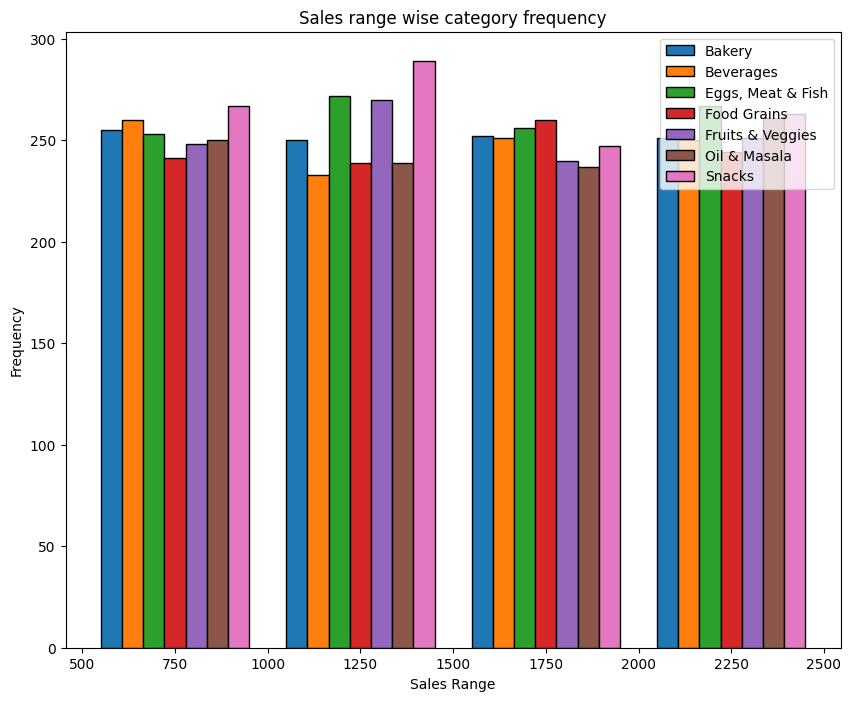

In [93]:
# Monthly sales range
category_sales = df.groupby('Category')['Sales'].unique()
print(category_sales, end='\n\n')

plt.figure(figsize=(10,8))
plt.hist(category_sales.values, bins=4, edgecolor='black',label=['Bakery','Beverages','Eggs, Meat & Fish','Food Grains','Fruits & Veggies','Oil & Masala','Snacks'])
plt.title("Sales range wise category frequency")
plt.legend()
plt.xlabel('Sales Range')
plt.ylabel('Frequency')
plt.show()

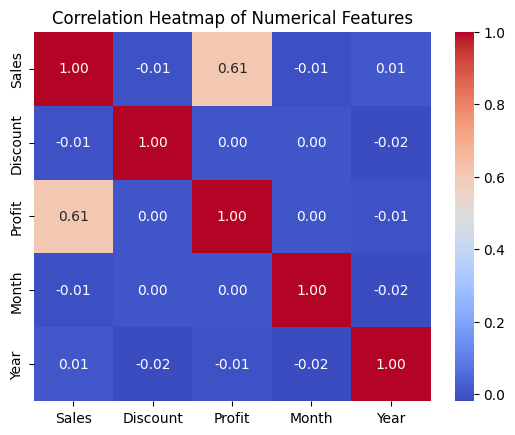

In [94]:
numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Prediction of next year(2019) sales and profits

### Importing Libraries

In [95]:
#Predictive Modeling – Sales & Profit Forecast

import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

### Training Model

In [96]:
# Step 1: Feature Preparation
df_model = df.copy()

# Month is already numeric
features = ['Year', 'Month', 'Category', 'Sub Category']
categorical_cols = ['Category', 'Sub Category']
numerical_cols = ['Year', 'Month']

# One-Hot Encode categorical columns
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_cats = encoder.fit_transform(df_model[categorical_cols])
encoded_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(categorical_cols))

X = pd.concat([df_model[numerical_cols].reset_index(drop=True), encoded_df], axis=1)
y_sales = df_model['Sales']
y_profit = df_model['Profit']

# Step 2: Train/Test Split for Evaluation
X_train, X_test, y_sales_train, y_sales_test, y_profit_train, y_profit_test = train_test_split(
    X, y_sales, y_profit, test_size=0.2, random_state=42
)

# Step 3: Train Random Forest Models
rf_sales = RandomForestRegressor(n_estimators=500, random_state=42)
rf_profit = RandomForestRegressor(n_estimators=500, random_state=42)

rf_sales.fit(X_train, y_sales_train)
rf_profit.fit(X_train, y_profit_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Predicting Next Year Trend


------Next Year Predicted Sales & Profit------
              Category        Sub Category  Predicted_Sales  Predicted_Profit
1               Bakery            Biscuits     6.567697e+05     165393.431419
2               Bakery       Breads & Buns     7.608101e+05     199351.076978
3               Bakery               Cakes     6.844984e+05     167939.335876
36           Beverages       Health Drinks     1.059610e+06     257865.598646
44           Beverages         Soft Drinks     1.090035e+06     266574.594622
50   Eggs, Meat & Fish             Chicken     4.811335e+05     115165.403430
55   Eggs, Meat & Fish                Eggs     5.850361e+05     136843.589573
56   Eggs, Meat & Fish                Fish     5.759961e+05     159522.690680
61   Eggs, Meat & Fish              Mutton     6.148049e+05     152734.352029
69         Food Grains        Atta & Flour     5.125244e+05     126331.259724
76         Food Grains       Dals & Pulses     5.149107e+05     121351.787666
87         Food 

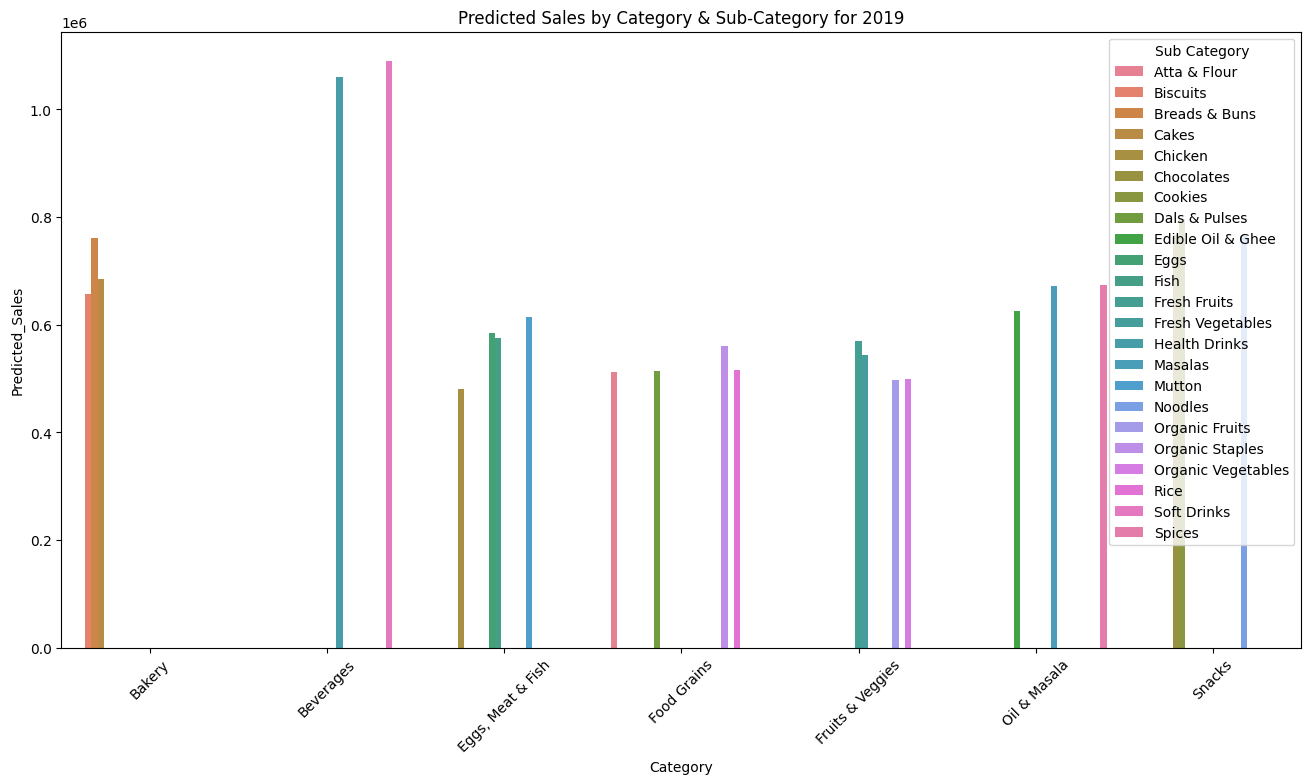

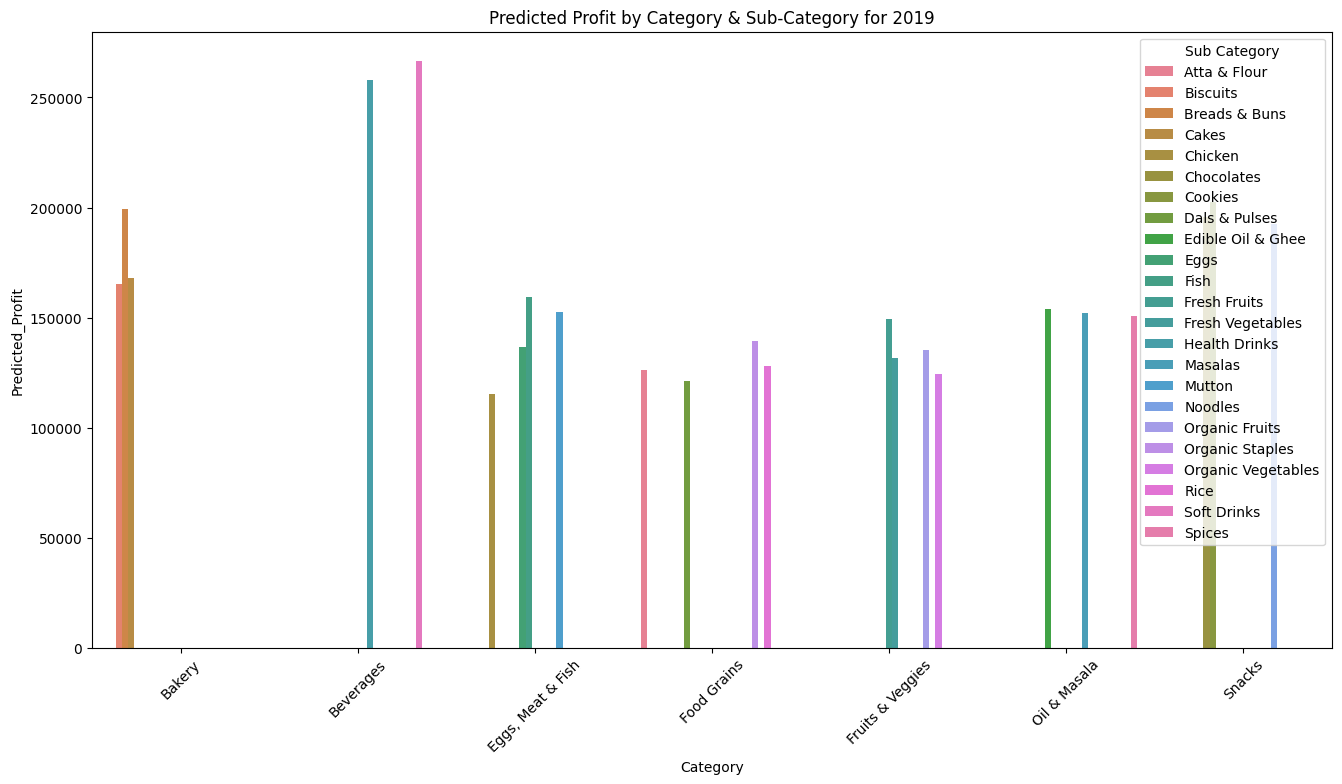

In [97]:
# Step 4: Evaluate Models on Test Set
sales_pred_test = rf_sales.predict(X_test)
profit_pred_test = rf_profit.predict(X_test)

# Step 5: Predict Next Year
future_year = df_model['Year'].max() + 1
future_data = df_model.copy()
future_data['Year'] = future_year

# Encode categorical columns for future data
encoded_future = encoder.transform(future_data[categorical_cols])
encoded_future_df = pd.DataFrame(encoded_future, columns=encoder.get_feature_names_out(categorical_cols))
future_X = pd.concat([future_data[numerical_cols].reset_index(drop=True), encoded_future_df], axis=1)

future_data['Predicted_Sales'] = rf_sales.predict(future_X)
future_data['Predicted_Profit'] = rf_profit.predict(future_X)

# Step 6: Group Predictions by Category & Sub-Category
future_summary = future_data.groupby(['Category','Sub Category'])[['Predicted_Sales','Predicted_Profit']].sum().reset_index()
print("\n------Next Year Predicted Sales & Profit------")
print(future_summary[future_summary['Predicted_Sales'] > 0])

# Step 7: Visualization of Next Year Trend
plt.figure(figsize=(16,8))
sns.barplot(x='Category', y='Predicted_Sales', hue='Sub Category', data=future_summary)
plt.title(f"Predicted Sales by Category & Sub-Category for {future_year}")
plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()

plt.figure(figsize=(16,8))
sns.barplot(x='Category', y='Predicted_Profit', hue='Sub Category', data=future_summary)
plt.title(f"Predicted Profit by Category & Sub-Category for {future_year}")
plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()

### Comparison of Actual and Predicted Sales

In [55]:
# Step 8: Compare Predicted vs Actual (Historical Data)
df_model['Predicted_Sales'] = rf_sales.predict(X)
df_model['Predicted_Profit'] = rf_profit.predict(X)
comparison = df_model.groupby(['Category','Sub Category'])[['Sales','Predicted_Sales','Profit','Predicted_Profit']].sum().reset_index()
print("\n------Comparison: Actual vs Predicted (Historical Data)-----")
print(comparison[comparison['Sales'] > 0])


------Comparison: Actual vs Predicted (Historical Data)-----
              Category        Sub Category    Sales  Predicted_Sales  \
1               Bakery            Biscuits   684083     6.812352e+05   
2               Bakery       Breads & Buns   742586     7.394213e+05   
3               Bakery               Cakes   685612     6.847940e+05   
36           Beverages       Health Drinks  1051439     1.044305e+06   
44           Beverages         Soft Drinks  1033874     1.039911e+06   
50   Eggs, Meat & Fish             Chicken   520497     5.220581e+05   
55   Eggs, Meat & Fish                Eggs   575156     5.728778e+05   
56   Eggs, Meat & Fish                Fish   560548     5.528719e+05   
61   Eggs, Meat & Fish              Mutton   611200     6.186496e+05   
69         Food Grains        Atta & Flour   534649     5.282987e+05   
76         Food Grains       Dals & Pulses   523371     5.205251e+05   
87         Food Grains     Organic Staples   558929     5.669291e+05   
89

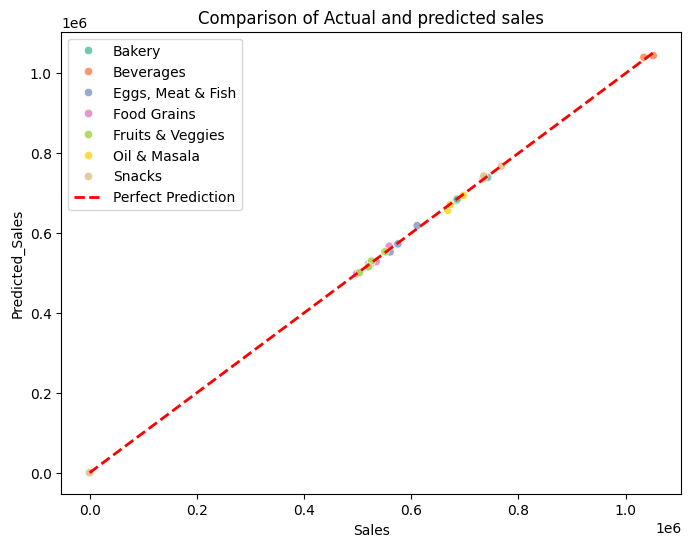

In [98]:
# visulixation
plt.figure(figsize=(8,6))
sns.scatterplot(data=comparison, x="Sales", y="Predicted_Sales", hue="Category", alpha=0.9, palette="Set2")
min_val = comparison[['Sales','Predicted_Sales']].min().min()
max_val = comparison[['Sales','Predicted_Sales']].max().max()
plt.plot([min_val, max_val], [min_val, max_val], '--', color='red', linewidth=2, label='Perfect Prediction')
plt.legend()
plt.title("Comparison of Actual and predicted sales")
plt.show()

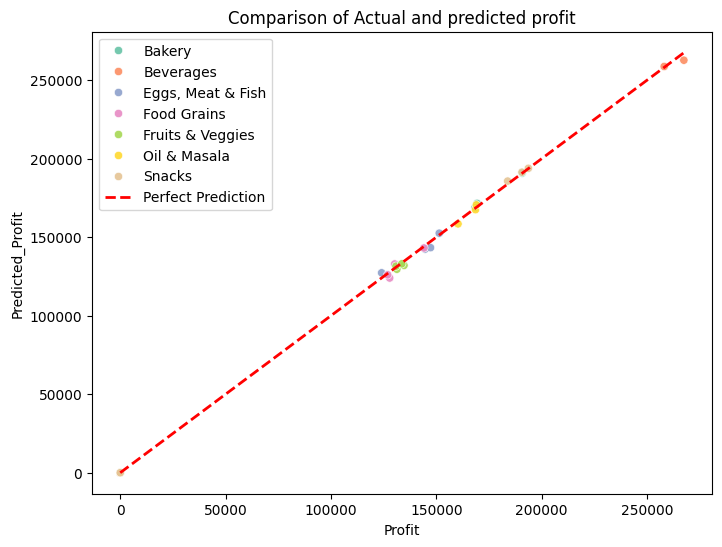

In [99]:
# visulixation
plt.figure(figsize=(8,6))
sns.scatterplot(data=comparison, x="Profit", y="Predicted_Profit", hue="Category", alpha=0.9, palette="Set2")
min_val = comparison[['Profit','Predicted_Profit']].min().min()
max_val = comparison[['Profit','Predicted_Profit']].max().max()
plt.plot([min_val, max_val], [min_val, max_val], '--', color='red', linewidth=2, label='Perfect Prediction')
plt.legend()
plt.title("Comparison of Actual and predicted profit")
plt.show()

## Conclusion

This project analyzed DMart grocery sales data from Tamil Nadu to understand product performance across cities, categories, and regions. The goal was to identify top-performing product categories and predict next year’s (2019) sales and profit trends using a Random Forest Regression model.

Through exploratory data analysis (EDA), it was observed that:

    - Snacks, Eggs, Meat & Fish, and Fruits & Veggies generated the highest overall profit.

    - Health Drinks, Soft Drinks, and Cookies were leading subcategories in both sales and profit.

    - The West and East regions contributed the most to overall revenue and profit.

The Random Forest model provided a reasonable estimation for future trends, showing close alignment between actual and predicted values across most product groups.
However, residual and scatter plots revealed some variance and bias, suggesting that model performance could be improved with additional feature engineering or advanced ensemble tuning.

#### Practical Impact

- The analysis helps optimize product-level strategies, such as adjusting discounts and inventory for high-demand items.

- Predictive insights guide future stock planning and marketing decisions to achieve targeted profits.

- Regional trend identification enables localized strategies to improve sales in underperforming areas.